#  IDP Pipeline Evaluation (with 7 examples and ou Vertex AI solution)


This notebook runs the **live pipeline** on documents found in `data/raw`, measures latency, and compares results against ground truth (if available in `data/ground_truth`).

### Prerequisites
1. Put images (png, jpg) in `data/raw/`.
2. (Optional) Put expected JSON files in `data/ground_truth/` with the same filename (e.g. `invoice_01.png` -> `invoice_01.json`).

In [29]:
import os
import sys
import time
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


if os.path.exists("src"):
    sys.path.append(os.path.join(os.getcwd(), "src"))
elif os.path.exists("../src"):
    sys.path.append(os.path.join(os.path.abspath(".."), "src"))

try:
    from idp.pipeline import Pipeline
except ImportError:
    print(" Error: Could not import 'src'. Make sure you are running this notebook from the project root.")

RAW_DIR = Path("data/raw")
GT_DIR = Path("data/ground_truth")
OUTPUT_DIR = Path("data/processed_eval")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

## 1. Helper Functions

In [30]:
def calculate_accuracy(pred: dict, truth: dict) -> float:
    if not truth: return 0.0
    
    matches = 0
    total_fields = 0
    
    for key, val_true in truth.items():
        if key.startswith("_") or isinstance(val_true, (dict, list)):
            continue
            
        total_fields += 1
        val_pred = pred.get(key)
        
        if str(val_pred).strip().lower() == str(val_true).strip().lower():
            matches += 1
            
    return matches / total_fields if total_fields > 0 else 0.0

## 2. Run Live Pipeline Test
This loop processes every image in `data/raw` using the actual `Pipeline` class and our solution in Vertex ai.

In [31]:
try:
    pipeline = Pipeline() # Will use default provider (Vertex or Ollama )
    print("Pipeline loaded successfully.")
except Exception as e:
    print(f"Failed to load Pipeline: {e}")
    pipeline = None

results = []

if pipeline:
    images = list(RAW_DIR.rglob("*.png")) + list(RAW_DIR.rglob("*.jpg")) + list(RAW_DIR.rglob("*.jpeg"))
    
    print(f"Found {len(images)} documents to process.\n")

    for img_path in images:
        print(f"Processing: {img_path.name} ...", end=" ")
        
        start_time = time.time()
        success = False
        accuracy = None
        pred_data = {}
        
        try:
            output_json_path = pipeline.process_and_save(str(img_path), str(OUTPUT_DIR))
            
            with open(output_json_path, 'r', encoding='utf-8') as f:
                pred_data = json.load(f)
            success = True
            
        except Exception as e:
            print(f"[ERROR] {e}", end=" ")
        
        latency = time.time() - start_time
        
        gt_file = GT_DIR / f"{img_path.stem}.json"
        if gt_file.exists():
            try:
                with open(gt_file, 'r', encoding='utf-8') as f:
                    truth_data = json.load(f)
                accuracy = calculate_accuracy(pred_data, truth_data)
            except Exception as e:
                print(f"(GT Error: {e})", end=" ")
        
        print(f"Done ({latency:.2f}s)" + (f" | Acc: {accuracy:.2f}" if accuracy is not None else ""))
        
        results.append({
            "Document": img_path.name,
            "Type": pred_data.get("document_type", "Unknown"),
            "Latency (s)": latency,
            "Accuracy": accuracy if accuracy is not None else 0.0,
            "GT Available": accuracy is not None,
            "Success": success
        })

    df = pd.DataFrame(results)

Pipeline loaded successfully.
Found 7 documents to process.

Processing: modele-facture-fr-classique-blanc-750px.png ...  Running OCR with provider: vertex
Done (34.55s) | Acc: 1.00
Processing: R (2).jpg ...  Running OCR with provider: vertex
Done (126.82s) | Acc: 1.00
Processing: facture-vierge.jpg ...  Running OCR with provider: vertex
Done (49.56s) | Acc: 0.83
Processing: modele-facture-4.jpg ...  Running OCR with provider: vertex
Done (89.92s) | Acc: 0.83
Processing: navy-invoice-template-centered-en.jpg ...  Running OCR with provider: vertex
Done (27.05s) | Acc: 0.75
Processing: dekolonila-visum-formatkey-jpg-w983.jpg ...  Running OCR with provider: vertex
Done (60.22s) | Acc: 1.00
Processing: Nouveau-passeport.jpg ...  Running OCR with provider: vertex
Done (28.57s) | Acc: 0.33


## 3. Results Analysis

,Document,Type,Latency (s),Accuracy,GT Available,Success
0,modele-facture-fr-classique-blanc-750px.png,invoice,34.548515,1.000000,True,True
1,R (2).jpg,generic_form,126.824697,1.000000,True,True
2,facture-vierge.jpg,invoice,49.560720,0.833333,True,True
3,modele-facture-4.jpg,invoice,89.923262,0.833333,True,True
4,navy-invoice-template-centered-en.jpg,invoice,27.048894,0.750000,True,True
5,dekolonila-visum-formatkey-jpg-w983.jpg,generic_form,60.222840,1.000000,True,True
6,Nouveau-passeport.jpg,generic_form,28.569672,0.333333,True,True


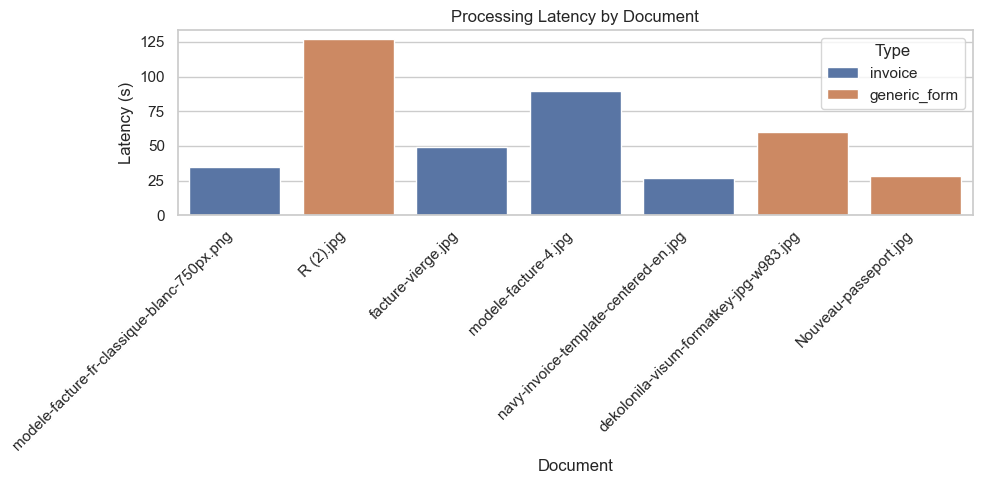

C:\Users\evanf\AppData\Local\Temp\ipykernel_11112\1184527933.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df["GT Available"]], x="Document", y="Accuracy", palette="viridis")


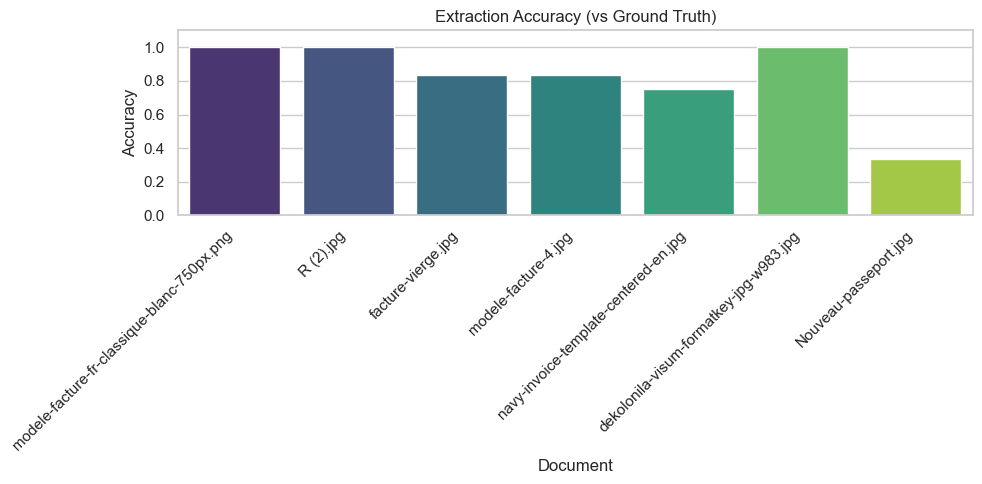

In [32]:
if not df.empty:
    display(df)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x="Document", y="Latency (s)", hue="Type", dodge=False)
    plt.title("Processing Latency by Document")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    
    if df["GT Available"].any():
        plt.figure(figsize=(10, 5))
        sns.barplot(data=df[df["GT Available"]], x="Document", y="Accuracy", palette="viridis")
        plt.title("Extraction Accuracy (vs Ground Truth)")
        plt.ylim(0, 1.1)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No Ground Truth files found in data/ground_truth/. Accuracy plot skipped.")
        
else:
    print(" No data processed. Check if 'data/raw' contains images.")

We can see that the data is well extracted, except for a few bugs with the invoices addresses and a discrepancy in the analysis of one of the passports/visas containing a lot of blur. The model works quite well.

In [33]:
if not df.empty and df.iloc[0]['Success']:
    sample_doc = df.iloc[0]['Document']
    print(f"### Sample Extraction: {sample_doc} ###\n")
    
    json_path = OUTPUT_DIR / f"{Path(sample_doc).stem}.json"
    if json_path.exists():
        with open(json_path, 'r') as f:
            print(json.dumps(json.load(f), indent=2))

### Sample Extraction: modele-facture-fr-classique-blanc-750px.png ###

{
  "document_type": "invoice",
  "invoice_number": "FR-001",
  "date": "29/01/2019",
  "seller_name": "Joanna Binet",
  "seller_address": "48 Coubertin\n31400 Paris",
  "buyer_name": "Cendrillon Ayot",
  "buyer_address": "69 rue Nations\n22000 Paris",
  "items": [
    {
      "description": "Grand brun escargot pour manger",
      "quantity": 1.0,
      "unit_price": 100.0,
      "total_price": 100.0
    },
    {
      "description": "Petit marini\u00c3\u00a8re uniforme en bleu",
      "quantity": 2.0,
      "unit_price": 15.0,
      "total_price": 30.0
    },
    {
      "description": "Facile \u00c3\u00a0 jouer accord\u00c3\u00a9on",
      "quantity": 3.0,
      "unit_price": 5.0,
      "total_price": 15.0
    }
  ],
  "subtotal": 145.0,
  "tax_amount": 29.0,
  "total_amount": 174.0,
  "currency": "\u00e2\u201a\u00ac",
  "language": "fr"
}
